In [2]:
# Import libraries
import pandas as pd
import numpy as np
import os
from datetime import datetime

# Configuration
N_SAMPLES = 50000
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("STEP 2: SYNTHETIC DATA GENERATION")
print("="*80)
print(f"Samples: {N_SAMPLES:,}")
print(f"Random Seed: {RANDOM_STATE}")
print(f"Target Default Rate: ~22%")

STEP 2: SYNTHETIC DATA GENERATION
Samples: 50,000
Random Seed: 42
Target Default Rate: ~22%


In [3]:
# Initialize data dictionary
data = {}

print("[1/6] Generating Socio-Economic Features...")

# C1: Income Tier (1-5)
data['income_tier'] = np.random.choice(
    [1, 2, 3, 4, 5],
    size=N_SAMPLES,
    p=[0.15, 0.30, 0.35, 0.15, 0.05]
)

# C2: Employment Type depends on income
employment_options = {
    1: ['Gig_Worker', 'Unemployed', 'Student'],
    2: ['Gig_Worker', 'Self_Employed', 'Salaried'],
    3: ['Salaried', 'Self_Employed', 'Gig_Worker'],
    4: ['Salaried', 'Self_Employed'],
    5: ['Salaried', 'Self_Employed']
}

employment_list = []
for income in data['income_tier']:
    choices = employment_options[income]
    employment_list.append(np.random.choice(choices))
data['employment_type'] = np.array(employment_list)

# C3: Employment Tenure
base_tenure = np.random.gamma(shape=2, scale=15, size=N_SAMPLES)
tenure_multiplier = np.where(
    data['employment_type'] == 'Salaried', 1.5,
    np.where(data['employment_type'] == 'Gig_Worker', 0.6, 1.0)
)
data['employment_tenure_months'] = np.clip(
    base_tenure * tenure_multiplier, 0, 600
).astype(int)

# C4: Education Level
data['education_level'] = np.clip(
    data['income_tier'] + np.random.randint(-1, 2, N_SAMPLES),
    1, 5
)

# C5: Residence Stability
data['residence_stability_years'] = np.clip(
    np.random.gamma(shape=2, scale=3, size=N_SAMPLES),
    0, 50
).astype(int)

# C6: Dependents Count
data['dependents_count'] = np.random.choice(
    [0, 1, 2, 3, 4, 5],
    size=N_SAMPLES,
    p=[0.25, 0.25, 0.25, 0.15, 0.07, 0.03]
)

print("Created: income_tier, employment_type, employment_tenure_months")
print("Created: education_level, residence_stability_years, dependents_count")

[1/6] Generating Socio-Economic Features...
Created: income_tier, employment_type, employment_tenure_months
Created: education_level, residence_stability_years, dependents_count


In [4]:
print("[2/6] Generating Behavioral Transaction Features...")

income = np.array(data['income_tier'])
employment = np.array(data['employment_type'])

# A1: UPI Transaction Frequency
base_txn = np.random.poisson(lam=20, size=N_SAMPLES)
data['upi_txn_frequency'] = np.clip(
    base_txn * (1 + income * 0.3), 0, 500
).astype(int)

# A2: Payment Delay Days (critical feature)
base_delay = np.random.exponential(scale=5, size=N_SAMPLES)

delay_multiplier = np.ones(N_SAMPLES)
delay_multiplier[income <= 2] *= 2.5
delay_multiplier[employment == 'Gig_Worker'] *= 2.0
delay_multiplier[employment == 'Unemployed'] *= 3.0
delay_multiplier[employment == 'Salaried'] *= 0.5

data['avg_payment_delay_days'] = np.clip(
    base_delay * delay_multiplier, 0, 90
)

# A3: Bill Payment Consistency
data['bill_payment_consistency'] = np.clip(
    1.0 - (data['avg_payment_delay_days'] / 90) + 
    np.random.normal(0, 0.1, N_SAMPLES),
    0.0, 1.0
)

# A4: Spending Volatility
base_volatility = np.random.gamma(shape=2, scale=0.3, size=N_SAMPLES)

vol_multiplier = np.ones(N_SAMPLES)
vol_multiplier[employment == 'Gig_Worker'] *= 2.5
vol_multiplier[employment == 'Unemployed'] *= 3.0
vol_multiplier[employment == 'Salaried'] *= 0.5
vol_multiplier[income >= 4] *= 0.6

data['spending_volatility_cv'] = np.clip(
    base_volatility * vol_multiplier, 0, 5.0
)

# A5: Savings Ratio
base_savings = np.random.beta(a=2, b=5, size=N_SAMPLES)
data['savings_ratio'] = np.clip(
    base_savings * (income / 5), 0, 0.8
)

# A6: Utility Autopay Flag
autopay_prob = 0.3 + (income / 5) * 0.4
data['utility_auto_payment_flag'] = np.random.binomial(
    1, autopay_prob, N_SAMPLES
)

# A7: Bounce Rate
data['bounce_rate_txn'] = np.clip(
    (data['avg_payment_delay_days'] / 90) * 0.5 + 
    np.random.beta(1, 10, N_SAMPLES),
    0.0, 1.0
)

# A8: Wallet Minimum Balance
data['wallet_min_balance'] = np.clip(
    np.random.gamma(shape=2, scale=500, size=N_SAMPLES) * income,
    0, 50000
)

# A9: Merchant Diversity Score
data['merchant_diversity_score'] = np.clip(
    np.random.poisson(lam=10, size=N_SAMPLES) + income * 2,
    1, 100
)

print("Created 9 behavioral features")

[2/6] Generating Behavioral Transaction Features...
Created 9 behavioral features


In [ ]:
print("[3/6] Generating Digital Footprint Features...")

# B1: App Usage Regularity (Out of 365 days how many days user uses app)
usage_prob = 0.6 + income * 0.05
data['app_usage_regularity_days'] = np.clip(
    np.random.binomial(n=365, p=usage_prob, size=N_SAMPLES),
    0, 365
)

# B2: Device Stability
data['device_stability_score'] = np.clip(
    np.random.beta(a=5, b=2, size=N_SAMPLES) + 
    (data['residence_stability_years'] / 50) * 0.2,
    0.0, 1.0
)

# B3: E-commerce Transaction Frequency
data['ecommerce_txn_frequency'] = np.clip(
    np.random.poisson(lam=3, size=N_SAMPLES) * income,
    0, 100
)

# B4: Recharge Regularity
data['recharge_regularity'] = np.clip(
    np.random.beta(a=8, b=2, size=N_SAMPLES),
    0, 1
)

# B5: Social Media Linked Flag
social_prob = 0.5 + (data['education_level'] / 5) * 0.3
data['social_media_linked_flag'] = np.random.binomial(
    1, social_prob, N_SAMPLES
)

# B6: KYC Completion Score
data['kyc_completion_score'] = np.random.choice(
    [0.5, 0.75, 1.0],
    size=N_SAMPLES,
    p=[0.05, 0.15, 0.80]
)

print("Created 6 digital features")

[3/6] Generating Digital Footprint Features...
Created 6 digital features


In [6]:
print("[4/6] Generating Stability Metrics...")

# D1: Loan Inquiry Count
inquiry_lambda = 2.0 - (income / 5) * 1.5
data['loan_inquiry_count_6m'] = np.clip(
    np.random.poisson(lam=inquiry_lambda, size=N_SAMPLES),
    0, 20
)

# D2: Existing Loan Flag
data['existing_loan_flag'] = np.random.choice(
    [0, 1], size=N_SAMPLES, p=[0.65, 0.35]
)

# D3: Insurance Ownership Flag
insurance_prob = 0.2 + (income / 5) * 0.5
data['insurance_ownership_flag'] = np.random.binomial(
    1, insurance_prob, N_SAMPLES
)

# D4: Account Age
data['account_age_months'] = np.clip(
    np.random.gamma(shape=3, scale=20, size=N_SAMPLES),
    0, 360
).astype(int)

print("Created 4 stability features")

[4/6] Generating Stability Metrics...
Created 4 stability features


In [ ]:
print("[5/6] Calculating Probability of Default...")

def norm(arr, min_val, max_val):
    # Normalize to 0-1 range
    return (np.array(arr) - min_val) / (max_val - min_val + 1e-8)

# Initialize PD score
pd_score = np.zeros(N_SAMPLES)

# Positive correlations (increase risk)
pd_score += 0.30 * norm(data['avg_payment_delay_days'], 0, 90)
pd_score += 0.25 * norm(data['spending_volatility_cv'], 0, 5)
pd_score += 0.20 * norm(data['bounce_rate_txn'], 0, 1)
pd_score += 0.12 * norm(data['loan_inquiry_count_6m'], 0, 20)
pd_score += 0.08 * norm(data['dependents_count'], 0, 10)
pd_score += 0.06 * data['existing_loan_flag']
pd_score += 0.10 * (employment == 'Gig_Worker').astype(int)
pd_score += 0.12 * (employment == 'Unemployed').astype(int)

# Negative correlations (decrease risk)
pd_score -= 0.25 * norm(income, 1, 5)
pd_score -= 0.20 * norm(data['bill_payment_consistency'], 0, 1)
pd_score -= 0.15 * norm(data['account_age_months'], 0, 360)
pd_score -= 0.12 * norm(data['kyc_completion_score'], 0, 1)
pd_score -= 0.10 * norm(data['upi_txn_frequency'], 0, 500)
pd_score -= 0.10 * norm(data['employment_tenure_months'], 0, 600)
pd_score -= 0.08 * norm(data['device_stability_score'], 0, 1)
pd_score -= 0.08 * norm(data['savings_ratio'], 0, 0.8)
pd_score -= 0.08 * norm(data['recharge_regularity'], 0, 1)
pd_score -= 0.06 * norm(data['residence_stability_years'], 0, 50)
pd_score -= 0.06 * norm(data['app_usage_regularity_days'], 0, 365)
pd_score -= 0.06 * norm(data['education_level'], 1, 5)
pd_score -= 0.06 * norm(data['wallet_min_balance'], 0, 50000)
pd_score -= 0.05 * data['insurance_ownership_flag']
pd_score -= 0.05 * norm(data['ecommerce_txn_frequency'], 0, 100)
pd_score -= 0.04 * data['utility_auto_payment_flag']
pd_score -= 0.04 * norm(data['merchant_diversity_score'], 1, 100)
pd_score -= 0.03 * data['social_media_linked_flag']

# Add noise
pd_score += np.random.normal(0, 0.08, N_SAMPLES)

# Sigmoid transformation converts score (0-1 range)
#* 4 Separates risky vs safe users better
pd_probability = 1 / (1 + np.exp(-pd_score * 4))

data['pd_score'] = pd_probability

print(f"PD Score Range: [{pd_probability.min():.4f}, {pd_probability.max():.4f}]")
print(f"Mean PD: {pd_probability.mean():.4f}")

[5/6] Calculating Probability of Default...
PD Score Range: [0.0082, 0.9457]
Mean PD: 0.1400


In [ ]:
print("[6/6] Generating Default Labels...")

# Set threshold for ~22% default rate i.e 22% of users are highest risk users
threshold = np.percentile(pd_probability, 78)
data['default_flag'] = (pd_probability > threshold).astype(int)

actual_default_rate = data['default_flag'].mean()

print(f"PD Threshold: {threshold:.4f}")
print(f"Target Default Rate: 22.0%")
print(f"Actual Default Rate: {actual_default_rate*100:.2f}%")

[6/6] Generating Default Labels...
PD Threshold: 0.1861
Target Default Rate: 22.0%
Actual Default Rate: 22.00%


In [9]:
# Create DataFrame
df = pd.DataFrame(data)

print("\nDATA GENERATION COMPLETE")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1] - 1} (excluding target)")
print(f"Samples: {df.shape[0]:,}")

# Display first few rows
df.head()


DATA GENERATION COMPLETE
Shape: (50000, 27)
Features: 26 (excluding target)
Samples: 50,000


,income_tier,employment_type,employment_tenure_months,education_level,residence_stability_years,dependents_count,upi_txn_frequency,avg_payment_delay_days,bill_payment_consistency,spending_volatility_cv,...,ecommerce_txn_frequency,recharge_regularity,social_media_linked_flag,kyc_completion_score,loan_inquiry_count_6m,existing_loan_flag,insurance_ownership_flag,account_age_months,pd_score,default_flag
0,2,Gig_Worker,27,1,4,3,40,19.026109,0.841763,0.909225,...,2,0.901327,0,1.0,0,0,0,15,0.160954,0
1,5,Self_Employed,66,5,3,0,42,3.447501,0.773246,0.280324,...,10,0.833506,1,1.0,0,1,1,81,0.033687,0
2,3,Self_Employed,18,4,9,2,26,3.032418,0.832686,1.913300,...,6,0.935097,1,0.5,1,0,1,33,0.069475,0
3,3,Self_Employed,44,3,4,1,26,6.182045,0.966416,0.972937,...,9,0.856647,0,1.0,0,1,0,47,0.083412,0
4,2,Self_Employed,49,3,6,2,30,41.808930,0.674066,0.367610,...,8,0.677063,0,1.0,3,0,1,57,0.168310,0


In [15]:
print("DATA VALIDATION")
print("="*80)

# Check missing values
missing = df.isnull().sum().sum()
print(f"\nMissing Values: {missing}")

# Check duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

# Check feature ranges
print(f"\nFeature Range Validation:")
checks = [
    ('avg_payment_delay_days', 0, 90),
    ('income_tier', 1, 5),
    ('bill_payment_consistency', 0, 1),
    ('spending_volatility_cv', 0, 5),
    ('savings_ratio', 0, 0.8)
]

all_pass = True
for feature, min_val, max_val in checks:
    actual_min = df[feature].min()
    actual_max = df[feature].max()
    if actual_min < min_val or actual_max > max_val:
        print(f"  ERROR: {feature}: [{actual_min:.2f}, {actual_max:.2f}]")
        all_pass = False

if all_pass:
    print("  All features within expected ranges")

DATA VALIDATION

Missing Values: 0
Duplicate Rows: 0

Feature Range Validation:
  All features within expected ranges


In [16]:
print("EXPLORATORY ANALYSIS")
print("="*80)

# Default rate by income
print("\nDefault Rate by Income Tier:")
default_by_income = df.groupby('income_tier')['default_flag'].agg(['mean', 'count'])
default_by_income.columns = ['Default_Rate', 'Count']
default_by_income['Default_Rate'] = (default_by_income['Default_Rate'] * 100).round(2)
print(default_by_income)

# Default rate by employment
print("\nDefault Rate by Employment Type:")
default_by_employment = df.groupby('employment_type')['default_flag'].agg(['mean', 'count'])
default_by_employment.columns = ['Default_Rate', 'Count']
default_by_employment['Default_Rate'] = (default_by_employment['Default_Rate'] * 100).round(2)
print(default_by_employment.sort_values('Default_Rate', ascending=False))

EXPLORATORY ANALYSIS

Default Rate by Income Tier:
             Default_Rate  Count
income_tier                     
1                   72.40   7533
2                   28.61  15049
3                    7.09  17492
4                    0.00   7456
5                    0.00   2470

Default Rate by Employment Type:
                 Default_Rate  Count
employment_type                     
Unemployed              92.61   2584
Gig_Worker              50.60  13306
Student                 36.43   2476
Self_Employed            4.57  15770
Salaried                 1.58  15864


In [19]:
print("="*80)
print("CORRELATION ANALYSIS WITH DEFAULT")
print("="*80)

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlations with default
correlations = numeric_df.corr()['default_flag'].sort_values(ascending=False)

# Remove self-correlation and pd_score
correlations = correlations.drop(['default_flag', 'pd_score'])

print("\n" + "="*80)
print("TOP 10 POSITIVE CORRELATIONS (Features that INCREASE default risk)")
print("="*80)
positive = correlations[correlations > 0].head(10)
for i, (feature, corr) in enumerate(positive.items(), 1):
    bar = "█" * int(corr * 50)
    print(f"{i:2d}. {feature:<35} {corr:>+.4f}  {bar}")

print("\n" + "="*80)
print("TOP 10 NEGATIVE CORRELATIONS (Features that DECREASE default risk)")
print("="*80)
negative = correlations[correlations < 0].tail(10).sort_values()
for i, (feature, corr) in enumerate(negative.items(), 1):
    bar = "█" * int(abs(corr) * 50)
    print(f"{i:2d}. {feature:<35} {corr:>+.4f}  {bar}")

print("\n" + "="*80)
print("CORRELATION STRENGTH GUIDE")
print("="*80)
print("""
|Correlation| Interpretation
-----------  ---------------
0.00 - 0.10  Very weak / No relationship
0.10 - 0.30  Weak
0.30 - 0.50  Moderate
0.50 - 0.70  Strong
0.70 - 1.00  Very Strong
""")

# Count by strength
strong_positive = (correlations > 0.5).sum()
strong_negative = (correlations < -0.5).sum()
moderate_positive = ((correlations > 0.3) & (correlations <= 0.5)).sum()
moderate_negative = ((correlations < -0.3) & (correlations >= -0.5)).sum()

print(f"Summary:")
print(f"  Strong positive correlations (>0.5):   {strong_positive}")
print(f"  Strong negative correlations (<-0.5):  {strong_negative}")
print(f"  Moderate positive (0.3 to 0.5):        {moderate_positive}")
print(f"  Moderate negative (-0.5 to -0.3):      {moderate_negative}")

CORRELATION ANALYSIS WITH DEFAULT

TOP 10 POSITIVE CORRELATIONS (Features that INCREASE default risk)
 1. avg_payment_delay_days              +0.6125  ██████████████████████████████
 2. spending_volatility_cv              +0.5007  █████████████████████████
 3. bounce_rate_txn                     +0.4656  ███████████████████████
 4. loan_inquiry_count_6m               +0.1640  ████████
 5. existing_loan_flag                  +0.0635  ███
 6. dependents_count                    +0.0305  █

TOP 10 NEGATIVE CORRELATIONS (Features that DECREASE default risk)
 1. bill_payment_consistency            -0.5693  ████████████████████████████
 2. income_tier                         -0.5151  █████████████████████████
 3. app_usage_regularity_days           -0.4726  ███████████████████████
 4. education_level                     -0.4092  ████████████████████
 5. upi_txn_frequency                   -0.3192  ███████████████
 6. merchant_diversity_score            -0.2962  ██████████████
 7. savings_rat

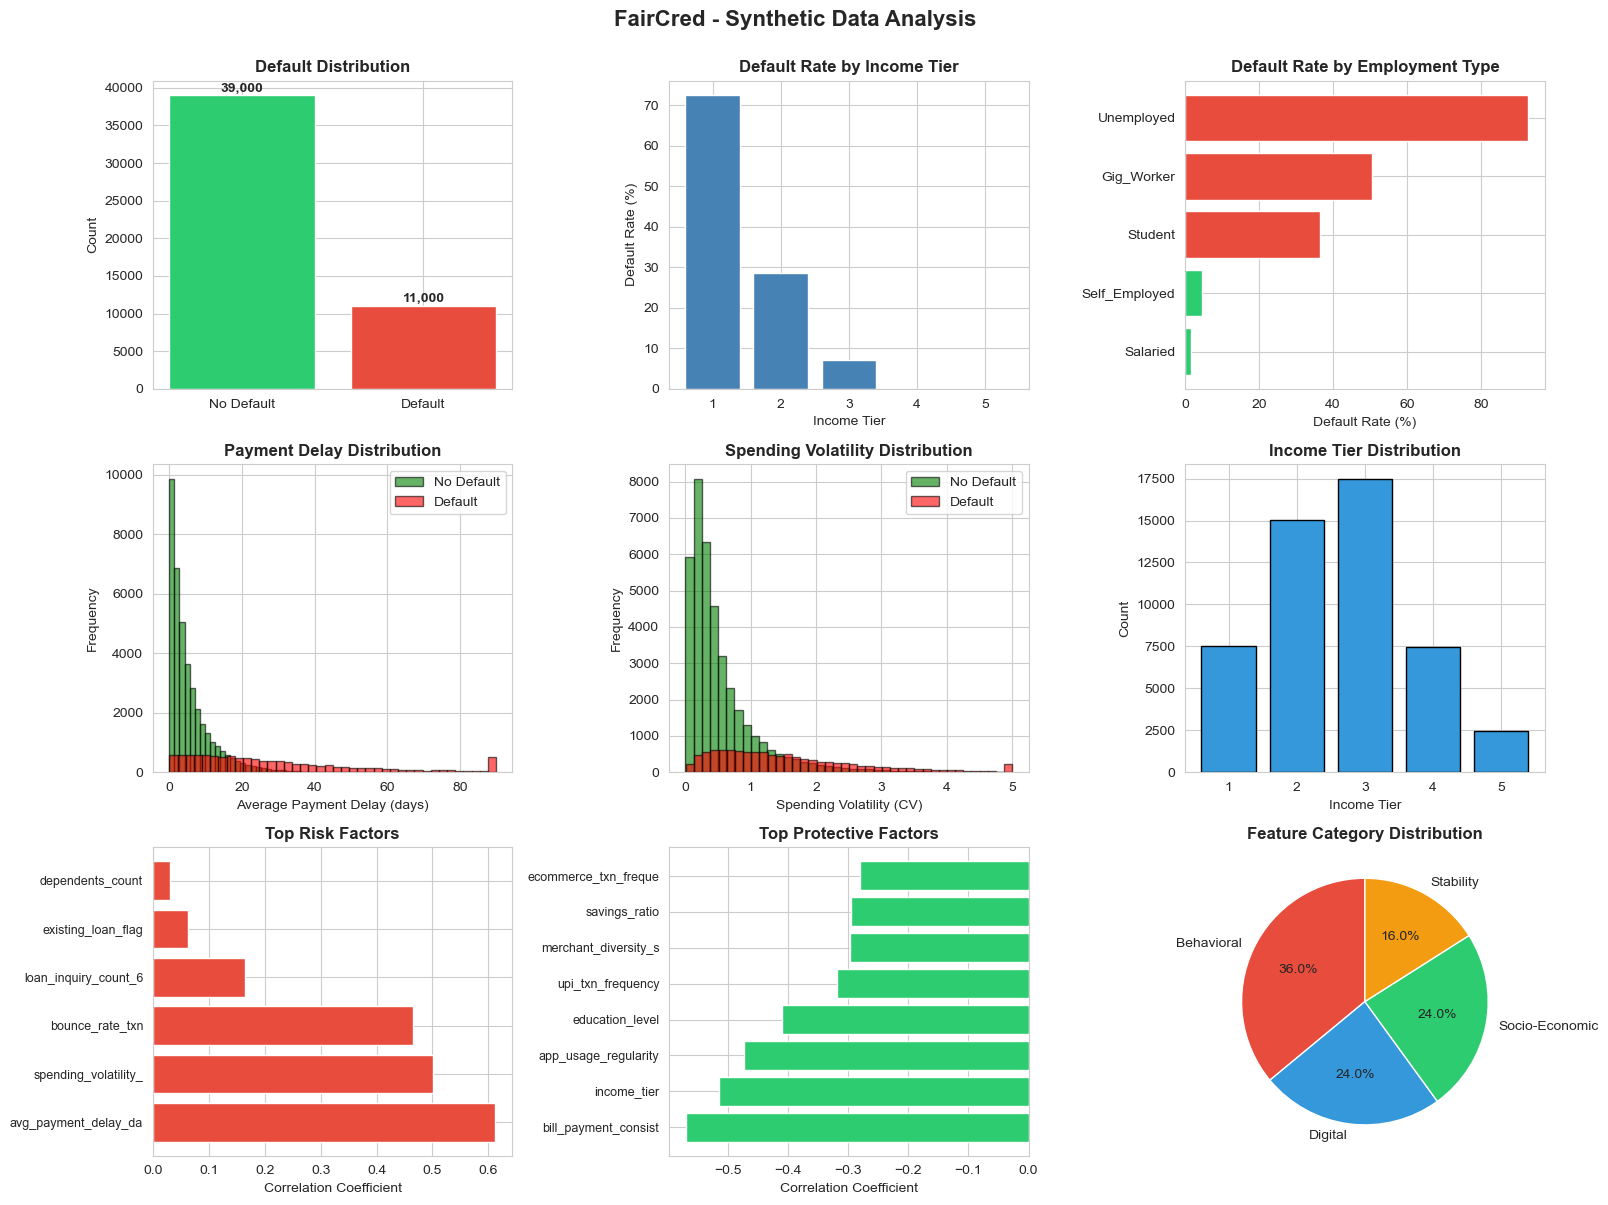

Visualization complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('FairCred - Synthetic Data Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Default Distribution
default_counts = df['default_flag'].value_counts()
axes[0, 0].bar(['No Default', 'Default'], default_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Default Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(default_counts.values):
    axes[0, 0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 2. Default Rate by Income Tier
default_by_income = df.groupby('income_tier')['default_flag'].mean() * 100
axes[0, 1].bar(default_by_income.index, default_by_income.values, color='steelblue')
axes[0, 1].set_title('Default Rate by Income Tier', fontweight='bold')
axes[0, 1].set_xlabel('Income Tier')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_xticks(range(1, 6))

# 3. Default Rate by Employment Type
default_by_emp = df.groupby('employment_type')['default_flag'].mean().sort_values(ascending=True) * 100
colors = ['#e74c3c' if x > 25 else '#f39c12' if x > 15 else '#2ecc71' for x in default_by_emp.values]
axes[0, 2].barh(range(len(default_by_emp)), default_by_emp.values, color=colors)
axes[0, 2].set_yticks(range(len(default_by_emp)))
axes[0, 2].set_yticklabels(default_by_emp.index)
axes[0, 2].set_title('Default Rate by Employment Type', fontweight='bold')
axes[0, 2].set_xlabel('Default Rate (%)')

# 4. Payment Delay Distribution
axes[1, 0].hist(df[df['default_flag']==0]['avg_payment_delay_days'], bins=40, 
                alpha=0.6, label='No Default', color='green', edgecolor='black')
axes[1, 0].hist(df[df['default_flag']==1]['avg_payment_delay_days'], bins=40, 
                alpha=0.6, label='Default', color='red', edgecolor='black')
axes[1, 0].set_title('Payment Delay Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Average Payment Delay (days)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 5. Spending Volatility Distribution
axes[1, 1].hist(df[df['default_flag']==0]['spending_volatility_cv'], bins=40, 
                alpha=0.6, label='No Default', color='green', edgecolor='black')
axes[1, 1].hist(df[df['default_flag']==1]['spending_volatility_cv'], bins=40, 
                alpha=0.6, label='Default', color='red', edgecolor='black')
axes[1, 1].set_title('Spending Volatility Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Spending Volatility (CV)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

# 6. Income Distribution
income_dist = df['income_tier'].value_counts().sort_index()
axes[1, 2].bar(income_dist.index, income_dist.values, color='#3498db', edgecolor='black')
axes[1, 2].set_title('Income Tier Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Income Tier')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_xticks(range(1, 6))

# 7. Top Positive Correlations
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['default_flag'].drop(['default_flag', 'pd_score'])
top_positive = correlations[correlations > 0].sort_values(ascending=False).head(8)
axes[2, 0].barh(range(len(top_positive)), top_positive.values, color='#e74c3c')
axes[2, 0].set_yticks(range(len(top_positive)))
axes[2, 0].set_yticklabels([x[:20] for x in top_positive.index], fontsize=9)
axes[2, 0].set_title('Top Risk Factors', fontweight='bold')
axes[2, 0].set_xlabel('Correlation Coefficient')

# 8. Top Negative Correlations
top_negative = correlations[correlations < 0].sort_values().head(8)
axes[2, 1].barh(range(len(top_negative)), top_negative.values, color='#2ecc71')
axes[2, 1].set_yticks(range(len(top_negative)))
axes[2, 1].set_yticklabels([x[:20] for x in top_negative.index], fontsize=9)
axes[2, 1].set_title('Top Protective Factors', fontweight='bold')
axes[2, 1].set_xlabel('Correlation Coefficient')

# 9. Feature Category Distribution
category_counts = {
    'Behavioral': 9,
    'Digital': 6,
    'Socio-Economic': 6,
    'Stability': 4
}
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
axes[2, 2].pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%',
               startangle=90, colors=colors_pie)
axes[2, 2].set_title('Feature Category Distribution', fontweight='bold')

plt.tight_layout()
plt.show()
